# 06 - Confronto tra coorti (anes vs awk)

Confronti EXP vs SHAM puramente entro la stessa coorte (es. EXP vs SHAM solo in anes) sono
poco informativi: le due coorti anes/awk sono animali disgiunti (date di scan diverse), quindi
non e' chiaro se una differenza rifletta l'effetto della lesione/DREADD o solo una differenza
di batch tra le coorti. Questo notebook si concentra invece sui confronti che usano la
struttura anes vs awk:

- **Bf_DTA**: flexibility per nodo, EXP vs SHAM, attraverso lo stato anes -> awk (interazione
  Group x State).
- **Bf_PV**: effetto specifico del CNO (difference-in-differences CNO - baseline, EXP vs SHAM)
  confrontato tra le coorti anes e awk, con test parametrico (Welch) + non parametrico
  (Mann-Whitney), correzione FDR (Benjamini-Hochberg) ed effect size (Hedges' g / rank-biserial).



## Setup and helper functions

Function and constant definitions used by the analysis cells below.


In [43]:
import os
import re
from collections import defaultdict
from glob import glob
import seaborn as sns
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, mannwhitneyu

In [44]:
OUTPUTS_DIR = "../outputs/community_detection"


def latest_leiden_output_dir(outputs_dir: str, dataset: str) -> str:
    """Return the most recently produced outputs/community_detection/leiden_flex_<n_runs>_<timestamp>/ dir containing `dataset`."""
    candidates = [
        d for d in glob(os.path.join(outputs_dir, "leiden_flex_*"))
        if os.path.isdir(os.path.join(d, dataset))
    ]
    assert candidates, f"No leiden_flex_* output directories containing {dataset!r} found in {outputs_dir}"
    return max(candidates, key=os.path.getmtime)




In [45]:
# Le cartelle soggetto hanno il formato "sub-<prefisso><data>", es. "sub-ag230908".
# All'interno, ogni scan e' "sub-<prefisso><data><topo>_<condition>...csv", es. "sub-ag230908a_EXP_bold_parcellated.csv".
SUBJECT_DIR_RE = re.compile(r"^sub-[a-zA-Z]+(\d+)$")


def build_subjects_by_date(output_dir, dataset):
    """Map each scan date to the sorted list of mouse letters scanned that day.

    Supports both repository output layouts:
      community detection: <dataset>/<preproc>/<date>/<scan>.csv
      parameter inspection: <dataset>/<date>/<mouse>/<scan>.csv
    """
    subjects_by_date = defaultdict(set)
    date_pattern = os.path.join(output_dir, dataset, "**", "sub-*")
    for subject_dir in glob(date_pattern, recursive=True):
        subject_folder = os.path.basename(subject_dir)
        match = SUBJECT_DIR_RE.match(subject_folder)
        if not match:
            continue
        date = match.group(1)
        for csv_path in glob(os.path.join(subject_dir, "**", "*.csv"), recursive=True):
            scan_id = os.path.basename(csv_path).split("_")[0]  # es. "sub-ag230908a"
            mouse = scan_id[len(subject_folder):]  # es. "a"
            if mouse:
                subjects_by_date[date].add(mouse)
    return {date: sorted(mice) for date, mice in sorted(subjects_by_date.items())}




In [46]:
DATASET_ANES = "Bf_DTA_anes"
DATASET_AWK = "Bf_DTA_awk"

DATASET_PV = "Bf_PV_anes"
DATASET_PV_AWK = "Bf_PV_awk"

def load_flex_long(dataset):
    """Tidy long-format flexibility table for `dataset`: one row per node per scan,
    with `mouse_id`, `condition` (EXP/SHAM) and `phase` (baseline/CNO/NA) columns.
    Reuses build_subjects_by_date."""
    leiden_dir = latest_leiden_output_dir(OUTPUTS_DIR, dataset)
    subjects_by_date = build_subjects_by_date(leiden_dir, dataset)

    # Store all the per-scan dataframes in a list, then concatenate them at the end.
    records = []
    for date, mice in subjects_by_date.items():
        for mouse in mice:
            csv_paths = glob(os.path.join(leiden_dir, dataset, "*", f"sub-*{date}", f"sub-*{date}{mouse}_*.csv"))
            for csv_path in csv_paths:
                fname = os.path.basename(csv_path)
                condition = fname.split("_")[1]  # "EXP" or "SHAM"
                # Bf_PV_* scans are split into baseline/CNO; Bf_DTA_* scans have no such split.
                if "baseline" in fname:
                    phase = "baseline"
                elif "CNO" in fname:
                    phase = "CNO"
                else:
                    phase = "NA"

                df = pd.read_csv(csv_path)

                # Add `mouse_id`, `condition`, `phase` columns to the dataframe
                df["mouse_id"] = f"{date}{mouse}"
                df["condition"] = condition
                df["phase"] = phase

                # Append it to the records list.
                records.append(df)

    # Concatenate all the per-scan dataframes into a single long-format dataframe and return it.
    return pd.concat(records, ignore_index=True)

## Effect size

Le statistiche dei test (t, U) e i p-value dicono se una differenza e' statisticamente
significativa, ma non quanto e' grande. Per il confronto EXP vs SHAM nel DiD qui sotto
aggiungiamo quindi **Hedges' g** (Cohen's d corretto per il bias da campioni piccoli) e la
**correlazione rank-biserial** (equivalente non parametrico di g, ricavata da U).

Non usiamo il relative risk: la nostra variabile di outcome (flexibility) e' continua, non
un evento binario/una proporzione, quindi RR non e' applicabile senza arbitrariamente
discretizzare i dati (perdendo informazione).

In [47]:
def hedges_g(x, y):
    """Bias-corrected Cohen's d (Hedges' g) for two independent samples."""
    x, y = np.asarray(x), np.asarray(y)
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    d = (x.mean() - y.mean()) / pooled_sd
    correction = 1 - 3 / (4 * (nx + ny - 2) - 1)
    return d * correction


def rank_biserial(u_stat, n1, n2):
    """Rank-biserial correlation from a Mann-Whitney U statistic (U for the first sample, x)."""
    return (2 * u_stat) / (n1 * n2) - 1

In [48]:
def benjamini_hochberg(pvals):
    """Return Benjamini-Hochberg FDR-adjusted p-values, in the input order."""
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    if n == 0:
        return p
    order = np.argsort(p)
    adjusted = p[order] * n / (np.arange(n) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]  # enforce monotonicity
    out = np.empty(n)
    out[order] = np.clip(adjusted, 0, 1)
    return out


def difference_in_differences(flex_df):
    """Per-node DiD test: is (CNO - baseline) different between EXP and SHAM?

    Expects a tidy frame with columns subject, condition, phase, Node, flexibility.
    Only animals that have BOTH phases contribute. Returns one row per node with
    raw Welch / Mann-Whitney p-values, their FDR-corrected counterparts, and effect sizes
    (Hedges' g for the Welch comparison, rank-biserial r for the Mann-Whitney one).
    """

    # Pivot to have one row per subject/condition/Node,
    # with separate columns for baseline and CNO flexibility.
    deltas = (
        flex_df
        .pivot_table(index=["subject", "condition", "Node"], columns="phase", values="flexibility")
        .dropna(subset=["baseline", "CNO"])
        .reset_index()
    )
    deltas["delta"] = deltas["CNO"] - deltas["baseline"]

    rows = []
    for node in sorted(deltas["Node"].unique()):
        d_exp = deltas.loc[(deltas.condition == "EXP") & (deltas.Node == node), "delta"]
        d_sham = deltas.loc[(deltas.condition == "SHAM") & (deltas.Node == node), "delta"]
        t_stat, t_p = ttest_ind(d_exp, d_sham, equal_var=False)
        u_stat, u_p = mannwhitneyu(d_exp, d_sham, alternative="two-sided")
        rows.append({
            "Node": node,
            "n_EXP": len(d_exp), "n_SHAM": len(d_sham),
            "delta_EXP": d_exp.mean(), "delta_SHAM": d_sham.mean(),
            "DiD": d_exp.mean() - d_sham.mean(),
            "t_p_value": t_p, "hedges_g": hedges_g(d_exp, d_sham),
            "u_p_value": u_p, "rank_biserial": rank_biserial(u_stat, len(d_exp), len(d_sham)),
        })
    res = pd.DataFrame(rows)
    res["t_p_fdr"] = benjamini_hochberg(res["t_p_value"])
    res["u_p_fdr"] = benjamini_hochberg(res["u_p_value"])
    return res.sort_values("t_p_value").reset_index(drop=True)




In [49]:
# Parameter inspection sweep: outputs/parameter_inspection/<run>/wl<width>/gamma_<g>_omega_<o>/<dataset>/...
# has the same <dataset>/sub-<prefix><date>/sub-<prefix><date><mouse>_<condition>...csv layout as the
# leiden_flex_* outputs above, just nested one level deeper (per width, per gamma/omega combo). We reuse
# build_subjects_by_date as-is for each combo and only add the directory-discovery helpers below.

PARAM_INSPECTION_DIR = "../outputs/parameter_inspection"


def latest_param_inspection_run_dir(outputs_dir: str) -> str:
    """Return the most recently produced outputs/parameter_inspection/<run_name>/ dir."""
    candidates = [d for d in glob(os.path.join(outputs_dir, "*")) if os.path.isdir(d)]
    assert candidates, f"No parameter inspection run directories found in {outputs_dir}"
    return max(candidates, key=os.path.getmtime)


def width_dirs(run_dir: str) -> list:
    """Sorted (by window length) list of wl<N> directories within a parameter inspection run."""
    return sorted(
        glob(os.path.join(run_dir, "wl*")),
        key=lambda d: int(re.match(r"wl(\d+)$", os.path.basename(d)).group(1)),
    )


def parameter_dirs(width_dir: str) -> list:
    """Sorted list of gamma_<g>_omega_<o> parameter-combo directories within a width dir."""
    return sorted(glob(os.path.join(width_dir, "gamma_*_omega_*")))


PARAM_RUN_DIR = latest_param_inspection_run_dir(PARAM_INSPECTION_DIR)


In [50]:
def node_stat_summary(flex_df, node_order):
    """Per-node summary stats for one (combo, condition) slice.

    flex_df: long-format with `Node` and `flexibility` columns, already filtered to a
    single condition. Outliers use the standard IQR rule (k=1.5) against each node's own
    distribution. Returns a DataFrame indexed by stat name, with one column per node.
    """
    stats = {}
    for node in node_order:
        vals = flex_df.loc[flex_df["Node"] == node, "flexibility"].to_numpy()
        q1, q3 = np.percentile(vals, [25, 75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        stats[node] = {
            "mean": vals.mean(),
            "median": np.median(vals),
            "std": vals.std(ddof=1),
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "n_outliers": int(((vals < lower) | (vals > upper)).sum()),
        }
    return pd.DataFrame(stats)[node_order]

In [51]:
# Return the results of the EXP vs SHAM t-tests for a given state
def exp_vs_sham_node_tests(flex_df, state):
    base_columns = ["state", "comparison", "Node", "t_p_value", "hedges_g", "u_p_value", "rank_biserial"]
    output_columns = [
        "state", "comparison", "Node",
        "t_p_value", "t_p_fdr", "hedges_g",
        "u_p_value", "u_p_fdr", "rank_biserial",
        "combo", "dataset", "window_length",
    ]
    rows = []
    for node in sorted(flex_df["Node"].unique()):
        x = flex_df.loc[(flex_df["condition"] == "EXP") & (flex_df["Node"] == node), "flexibility"]
        y = flex_df.loc[(flex_df["condition"] == "SHAM") & (flex_df["Node"] == node), "flexibility"]
        if x.empty or y.empty:
            continue

        t_stat, t_p = ttest_ind(x, y, equal_var=False)
        u_stat, u_p = mannwhitneyu(x, y, alternative="two-sided")

        rows.append({
            "state": state,
            "comparison": "EXP_vs_SHAM",
            "Node": node,
            "t_p_value": t_p,
            "hedges_g": hedges_g(x, y),
            "u_p_value": u_p,
            "rank_biserial": rank_biserial(u_stat, len(x), len(y)),
        })

    res = pd.DataFrame(rows, columns=base_columns)
    res["t_p_fdr"] = benjamini_hochberg(res["t_p_value"])
    res["u_p_fdr"] = benjamini_hochberg(res["u_p_value"])
    for column in ["combo", "dataset", "window_length"]:
        if column in flex_df.columns:
            values = flex_df[column].dropna().unique()
            res[column] = values[0] if len(values) == 1 else pd.NA
        else:
            res[column] = pd.NA
    return res[output_columns]




In [52]:
def pv_delta_exp_vs_sham_tests(flex_df, state):
    base_columns = ["state", "comparison", "Node", "t_p_value", "hedges_g", "u_p_value", "rank_biserial"]
    output_columns = [
        "state", "comparison", "Node",
        "t_p_value", "t_p_fdr", "hedges_g",
        "u_p_value", "u_p_fdr", "rank_biserial",
        "combo", "dataset", "window_length",
    ]
    deltas = (
        flex_df
        .rename(columns={"mouse_id": "subject"})
        .pivot_table(index=["subject", "condition", "Node"], columns="phase", values="flexibility")
    )
    for phase in ["baseline", "CNO"]:
        if phase not in deltas.columns:
            deltas[phase] = pd.NA
    deltas = deltas.dropna(subset=["baseline", "CNO"]).reset_index()
    deltas["delta"] = deltas["CNO"] - deltas["baseline"]

    rows = []
    for node in sorted(deltas["Node"].unique()):
        x = deltas.loc[(deltas["condition"] == "EXP") & (deltas["Node"] == node), "delta"]
        y = deltas.loc[(deltas["condition"] == "SHAM") & (deltas["Node"] == node), "delta"]
        if x.empty or y.empty:
            continue

        t_stat, t_p = ttest_ind(x, y, equal_var=False)
        u_stat, u_p = mannwhitneyu(x, y, alternative="two-sided")

        rows.append({
            "state": state,
            "comparison": "EXP_vs_SHAM_delta",
            "Node": node,
            "t_p_value": t_p,
            "hedges_g": hedges_g(x, y),
            "u_p_value": u_p,
            "rank_biserial": rank_biserial(u_stat, len(x), len(y)),
        })

    res = pd.DataFrame(rows, columns=base_columns)
    res["t_p_fdr"] = benjamini_hochberg(res["t_p_value"])
    res["u_p_fdr"] = benjamini_hochberg(res["u_p_value"])
    for column in ["combo", "dataset", "window_length"]:
        if column in flex_df.columns:
            values = flex_df[column].dropna().unique()
            res[column] = values[0] if len(values) == 1 else pd.NA
        else:
            res[column] = pd.NA
    return res[output_columns]




In [53]:
def build_parameter_stats(run_dir=PARAM_RUN_DIR, datasets=(DATASET_ANES, DATASET_AWK, DATASET_PV, DATASET_PV_AWK)):
    """Per-subject flexibility summary stats from the parameter-inspection sweep.

    Returns {window_length: DataFrame}, one tidy long-format DataFrame per window length with
    columns: dataset, combo, condition, date, subject, mean, median, std, iqr -- one row per
    mouse/scan CSV. Kept separate per window length (instead of one global frame) because
    window length isn't a comparison axis here: each width is inspected independently, and a
    single frame mixing widths would invite accidental cross-width aggregation. `datasets` is
    looped explicitly so multiple datasets (e.g. Bf_DTA/Bf_PV, anes/awk) land in the same frame
    as a `dataset` column, filterable per analysis.
    """
    result = {}

    # Iterate over window length
    for window_dir in width_dirs(run_dir):
        window_length = int(re.match(r"wl(\d+)$", os.path.basename(window_dir)).group(1))
        rows = []
        
        # Iterate over parameter combos 
        for combo_dir in parameter_dirs(window_dir):
            combo_name = os.path.basename(combo_dir)
            
            # Iterate over datasets
            for dataset in datasets:
                subjects_by_date = build_subjects_by_date(combo_dir, dataset)
                
                # Iterate over dates of mice
                for date, mice in subjects_by_date.items():

                    # Iterate over mice
                    for mouse in mice:
                        mouse_csv_paths = sorted(glob(os.path.join(
                            combo_dir,
                            dataset,
                            f"sub-*{date}",
                            f"sub-*{date}{mouse}",
                            "*.csv",
                        )))

                        for csv_path in mouse_csv_paths:
                            condition = os.path.basename(csv_path).split("_")[1]
                            flexibility_vector = pd.read_csv(csv_path)["flexibility"].to_numpy()
                            q1, q3 = np.percentile(flexibility_vector, [25, 75])

                            rows.append({
                                "dataset": dataset,
                                "combo": combo_name,
                                "condition": condition,
                                "date": date,
                                "subject": f"{date}{mouse}",
                                "mean": flexibility_vector.mean(),
                                "median": np.median(flexibility_vector),
                                "std": flexibility_vector.std(ddof=1),
                                "iqr": q3 - q1,
                            })

        result[window_length] = pd.DataFrame(rows)

    return result




In [54]:
DATASET_STATE_RE = re.compile(r"^(.+)_(anes|awk)$")


def _parse_dataset_state(dataset_folder: str) -> tuple[str, str]:
    match = DATASET_STATE_RE.match(dataset_folder)
    assert match, f"Unexpected dataset folder name: {dataset_folder}"
    return match.group(1), match.group(2)


def load_param_flex_long(
    run_dir: str | None = None,
    window_length: int = 35,
    combo: str | None = None,
    datasets: tuple[str, ...] = (DATASET_ANES, DATASET_AWK, DATASET_PV, DATASET_PV_AWK),
) -> pd.DataFrame:
    """Tidy long-format flexibility table from a parameter-inspection sweep.

    Mirrors ``load_flex_long`` but reads the nested parameter-inspection layout:
      <run>/wl<N>/gamma_<g>_omega_<o>/<dataset>/sub-<prefix><date>/sub-<prefix><date><mouse>/<scan>.csv

    Returns one row per node per scan CSV, iterating every date and mouse under
    the requested window length / combo / dataset selection. Metadata columns:
    ``Node``, ``flexibility``, ``condition`` (EXP/SHAM), ``dataset`` (e.g. Bf_DTA),
    ``state`` (anes/awk), ``mouse_id``, ``date``, ``phase``, ``window_length``,
    ``combo``, ``gamma``, ``omega``.
    """
    if run_dir is None:
        run_dir = latest_param_inspection_run_dir(PARAM_INSPECTION_DIR)

    window_dir = os.path.join(run_dir, f"wl{window_length}")
    assert os.path.isdir(window_dir), f"No wl{window_length} directory under {run_dir}"

    combo_dirs = (
        [os.path.join(window_dir, combo)]
        if combo is not None
        else parameter_dirs(window_dir)
    )

    records = []
    for combo_dir in combo_dirs:
        combo_name = os.path.basename(combo_dir)
        gamma, omega = re.match(
            r"gamma_([\d.]+)_omega_([\d.]+)$", combo_name
        ).groups()

        for dataset in datasets:
            dataset_base, state = _parse_dataset_state(dataset)
            subjects_by_date = build_subjects_by_date(combo_dir, dataset)

            for date, mice in subjects_by_date.items():
                for mouse in mice:
                    csv_paths = sorted(glob(os.path.join(
                        combo_dir,
                        dataset,
                        f"sub-*{date}",
                        f"sub-*{date}{mouse}",
                        "*.csv",
                    )))

                    for csv_path in csv_paths:
                        fname = os.path.basename(csv_path)
                        condition = fname.split("_")[1]
                        if "baseline" in fname:
                            phase = "baseline"
                        elif "CNO" in fname:
                            phase = "CNO"
                        else:
                            phase = "NA"

                        df = pd.read_csv(csv_path)
                        df["mouse_id"] = f"{date}{mouse}"
                        df["date"] = date
                        df["condition"] = condition
                        df["phase"] = phase
                        df["dataset"] = dataset_base
                        df["state"] = state
                        df["window_length"] = window_length
                        df["combo"] = combo_name
                        df["gamma"] = float(gamma)
                        df["omega"] = float(omega)
                        records.append(df)

    if not records:
        return pd.DataFrame()

    return pd.concat(records, ignore_index=True)

In [55]:
PARAM_NODE_TEST_COLUMNS = [
    "state", "comparison", "Node",
    "t_p_value", "t_p_fdr", "hedges_g",
    "u_p_value", "u_p_fdr", "rank_biserial",
    "combo", "dataset", "window_length",
]

STATE_LABELS = {
    "anes": "anesthesia",
    "awk": "awake",
}


def empty_node_test_results():
    return pd.DataFrame(columns=PARAM_NODE_TEST_COLUMNS)


def run_parameter_pv_delta_tests(run_dir=None, dataset=DATASET_PV_AWK, state_label=None):
    """PV CNO-baseline delta EXP-vs-SHAM tests for every available width/combo."""
    if run_dir is None:
        run_dir = latest_param_inspection_run_dir(PARAM_INSPECTION_DIR)

    _, state_code = _parse_dataset_state(dataset)
    if state_label is None:
        state_label = STATE_LABELS.get(state_code, state_code)

    results = []
    for width_dir in width_dirs(run_dir):
        window_length = int(re.match(r"wl(\d+)$", os.path.basename(width_dir)).group(1))
        flex_param = load_param_flex_long(
            run_dir=run_dir,
            window_length=window_length,
            datasets=(dataset,),
        )
        if flex_param.empty:
            continue

        for combo, combo_df in flex_param.groupby("combo", sort=True):
            res = pv_delta_exp_vs_sham_tests(combo_df, state=state_label)
            if not res.empty:
                results.append(res)

    if not results:
        return empty_node_test_results()

    return (
        pd.concat(results, ignore_index=True)
        .loc[:, PARAM_NODE_TEST_COLUMNS]
        .sort_values(["window_length", "combo", "t_p_value", "Node"])
        .reset_index(drop=True)
    )

## Analysis


## Step 1 - Inventario dei dati

Prima di tutto esploriamo `outputs/community_detection/leiden_flex_*` per capire quali scan sono disponibili.
Organizziamo i soggetti in un dizionario `{data: [topi]}`:
- la chiave e' la data dello scan (es. `230908`)
- i valori sono le lettere dei topi scansionati quel giorno (es. `a`, `b`, `c`, `d`)

In [56]:
DATASET = "Bf_DTA_anes"
LEIDEN_DIR = latest_leiden_output_dir(OUTPUTS_DIR, DATASET)
LEIDEN_DIR

'../outputs/community_detection/leiden_flex_20_20260611_121947'

In [57]:
subjects_by_date = build_subjects_by_date(LEIDEN_DIR, DATASET)
subjects_by_date


{'230908': ['a'],
 '230911': ['a', 'b', 'c', 'd'],
 '230912': ['a', 'b', 'c', 'd'],
 '230913': ['a', 'b', 'c', 'd'],
 '230914': ['a', 'b', 'c', 'd'],
 '230915': ['a'],
 '230918': ['a', 'b', 'c', 'd'],
 '230919': ['a', 'b', 'c', 'd'],
 '230920': ['a', 'b', 'c'],
 '230921': ['a', 'b', 'c', 'd'],
 '230922': ['a', 'b', 'c', 'd'],
 '230925': ['a', 'b', 'c'],
 '230926': ['a', 'b']}

In [58]:
# Bf_PV dataset inventory (anes cohort): scan dates and mouse letters available,
# same structure as Bf_DTA_anes above.

DATASET_PV = "Bf_PV_anes"
LEIDEN_DIR_PV = latest_leiden_output_dir(OUTPUTS_DIR, DATASET_PV)
subjects_by_date_pv = build_subjects_by_date(LEIDEN_DIR_PV, DATASET_PV)
subjects_by_date_pv


{'240718': ['a', 'b'],
 '240719': ['b', 'c'],
 '240722': ['a'],
 '240723': ['a'],
 '240724': ['a', 'b', 'c'],
 '240725': ['a', 'b', 'c'],
 '240726': ['a', 'b', 'c'],
 '240729': ['a', 'b', 'c', 'd'],
 '240730': ['a', 'b', 'c', 'd'],
 '240731': ['a', 'b', 'c'],
 '240801': ['b', 'c', 'd'],
 '240802': ['a', 'c', 'd'],
 '240806': ['a', 'b', 'c'],
 '240807': ['a', 'b', 'c'],
 '240808': ['a', 'b', 'c']}

In [59]:
# Bf_DTA: flexibility by group (EXP/SHAM) x state (anes/awk), per node.
# This is the visual version of the Group x State interaction test: parallel
# EXP/SHAM lines across anes -> awk mean no state-dependence of the lesion effect;
# diverging/crossing lines mean anesthesia masks (or reveals) it.



state  condition
anes   EXP          22
       SHAM         20
awk    EXP          16
       SHAM         17
Name: mouse_id, dtype: int64


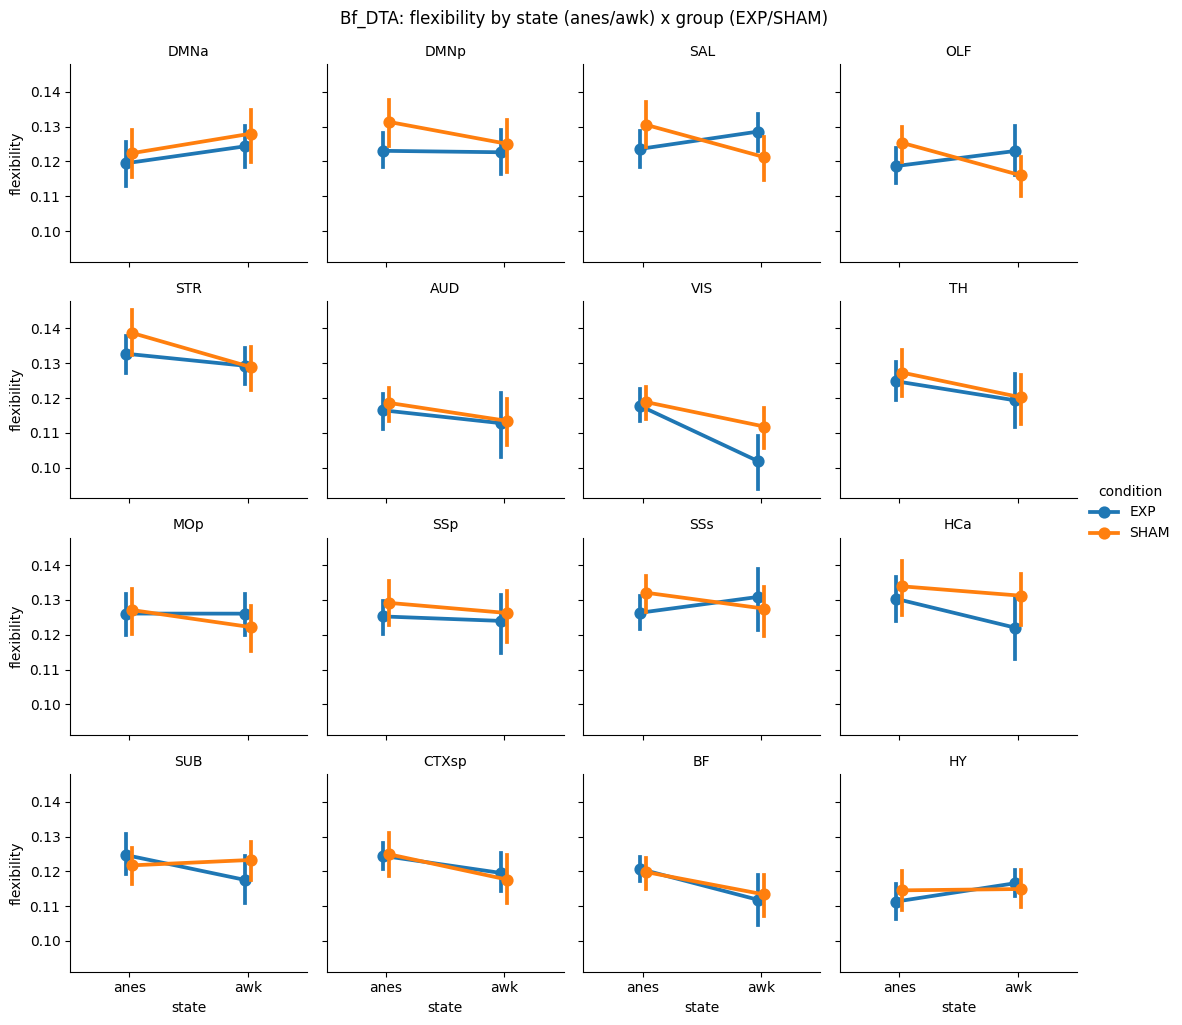

In [60]:

flex_dta = pd.concat([
    load_flex_long(DATASET_ANES).assign(state="anes"),
    load_flex_long(DATASET_AWK).assign(state="awk"),
], ignore_index=True)

print(flex_dta.drop_duplicates(["mouse_id", "condition", "state"]).groupby(["state", "condition"])["mouse_id"].nunique())

# Col = node splits the dataframe into one subset per node value
# X = state (anes/awk) is the x-axis
# Hue = condition (EXP/SHAM) is the color of the lines
# Flexibility is the y-axis, with 95% confidence intervals as error bars

g = sns.catplot(
    data=flex_dta, kind="point",
    x="state", y="flexibility", hue="condition",
    col="Node", col_wrap=4, dodge=True, errorbar=("ci", 95),
    height=2.5, aspect=1.1,
)
g.set_titles("{col_name}")
g.fig.suptitle("Bf_DTA: flexibility by state (anes/awk) x group (EXP/SHAM)", y=1.02)
plt.show()

In [61]:
flex_dta

,Node,flexibility,flexibility_std,gamma,interslice_weight,n_runs,n_windows,last_run,mouse_id,condition,phase,state
0,DMNa,0.100000,0.007110,0.35,0.25,20,650,11/06/2026 12:34,230908a,EXP,NA,anes
1,DMNp,0.117565,0.005515,0.35,0.25,20,650,11/06/2026 12:34,230908a,EXP,NA,anes
2,SAL,0.113790,0.007662,0.35,0.25,20,650,11/06/2026 12:34,230908a,EXP,NA,anes
3,OLF,0.130431,0.006981,0.35,0.25,20,650,11/06/2026 12:34,230908a,EXP,NA,anes
4,STR,0.131048,0.005051,0.35,0.25,20,650,11/06/2026 12:34,230908a,EXP,NA,anes
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,HCa,0.117244,0.008159,0.35,0.25,20,607,17/06/2026 15:51,231130e,EXP,NA,awk
1196,SUB,0.128878,0.007470,0.35,0.25,20,607,17/06/2026 15:51,231130e,EXP,NA,awk
1197,CTXsp,0.110314,0.007692,0.35,0.25,20,607,17/06/2026 15:51,231130e,EXP,NA,awk
1198,BF,0.127063,0.007098,0.35,0.25,20,607,17/06/2026 15:51,231130e,EXP,NA,awk


In [62]:
# Bf_PV: CNO-specific effect (difference-in-differences) compared anes vs awk.
# Comparing raw flexibility levels between Bf_PV_anes and Bf_PV_awk is confounded: the two
# state cohorts are disjoint animals (different scan dates), so any EXP vs SHAM gap could be a
# pre-existing batch difference rather than a CNO effect. The within-animal CNO-baseline delta
# cancels out each cohort's own baseline confound, so comparing
#   DiD_state = (EXP_CNO - EXP_baseline) - (SHAM_CNO - SHAM_baseline)
# between anes and awk is a true State x Condition x Phase test: "is the CNO-specific effect
# different in magnitude/sign when awake vs anesthetized?", not "is awake flexibility lower
# than anesthetized flexibility?".

flex_pv_state = pd.concat([
    load_flex_long(DATASET_PV).assign(state="anes"),
    load_flex_long(DATASET_PV_AWK).assign(state="awk"),
], ignore_index=True)

print(
    flex_pv_state
    .drop_duplicates(["mouse_id", "condition", "phase", "state"])
    .groupby(["state", "condition", "phase"])["mouse_id"]
    .nunique()
)


# difference_in_differences expects a "subject" column (it was written for phase_df,
# which uses that name); flex_pv_state uses "mouse_id" for the same thing.
flex_pv_state_for_did = flex_pv_state.rename(columns={"mouse_id": "subject"})

did_by_state = pd.concat([
    difference_in_differences(flex_pv_state_for_did.loc[flex_pv_state_for_did["state"] == "anes"]).assign(state="anes"),
    difference_in_differences(flex_pv_state_for_did.loc[flex_pv_state_for_did["state"] == "awk"]).assign(state="awk"),
], ignore_index=True)

did_by_state[["state", "Node", "n_EXP", "n_SHAM", "delta_EXP", "delta_SHAM", "DiD", "t_p_value", "t_p_fdr", "hedges_g", "u_p_value", "u_p_fdr", "rank_biserial"]]

state  condition  phase   
anes   EXP        CNO         21
                  baseline    21
       SHAM       CNO         20
                  baseline    18
awk    EXP        CNO          9
                  baseline    11
       SHAM       CNO          9
                  baseline     9
Name: mouse_id, dtype: int64


,state,Node,n_EXP,n_SHAM,delta_EXP,delta_SHAM,DiD,t_p_value,t_p_fdr,hedges_g,u_p_value,u_p_fdr,rank_biserial
0,anes,TH,21,18,-0.003241,0.004209,-0.007450,0.050283,0.315048,-0.628582,0.088307,0.275253,-0.322751
1,anes,SUB,21,18,-0.004314,0.004873,-0.009187,0.060491,0.315048,-0.630339,0.111451,0.275253,-0.301587
2,anes,VIS,21,18,-0.001127,0.006910,-0.008037,0.072354,0.315048,-0.581246,0.035835,0.275253,-0.396825
3,anes,HY,21,18,-0.002071,0.003680,-0.005751,0.084935,0.315048,-0.552282,0.117927,0.275253,-0.296296
4,anes,HCa,21,18,-0.003000,0.004351,-0.007351,0.120635,0.315048,-0.510018,0.154830,0.275253,-0.269841
5,anes,STR,21,18,-0.005714,0.002474,-0.008188,0.122986,0.315048,-0.508912,0.105258,0.275253,-0.306878
6,anes,DMNp,21,18,0.000437,0.007123,-0.006685,0.138632,0.315048,-0.480145,0.124695,0.275253,-0.291005
7,anes,SSp,21,18,-0.003352,0.003359,-0.006711,0.157524,0.315048,-0.466265,0.099342,0.275253,-0.312169
8,anes,DMNa,21,18,-0.002401,0.004820,-0.007221,0.179175,0.318533,-0.444506,0.139135,0.275253,-0.280423
9,anes,BF,21,18,-0.001546,0.004208,-0.005754,0.216614,0.346582,-0.396030,0.303822,0.441923,-0.195767


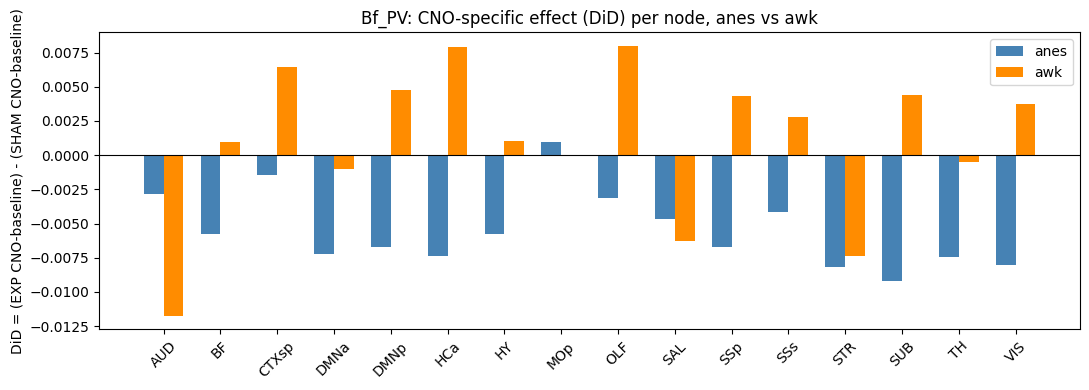

In [63]:
# Side-by-side per-node DiD comparison: bars above 0 mean EXP's CNO-baseline change is
# larger (less negative / more positive) than SHAM's; bars below 0 mean the opposite.
# Comparing the anes and awk bars per node shows where the two cohorts agree or disagree
# on the direction/magnitude of the CNO-specific effect.

node_order = sorted(did_by_state["Node"].unique())
did_pivot = did_by_state.pivot(index="Node", columns="state", values="DiD").reindex(node_order)

x = np.arange(len(node_order))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - width / 2, did_pivot["anes"], width=width, label="anes", color="steelblue")
ax.bar(x + width / 2, did_pivot["awk"], width=width, label="awk", color="darkorange")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(node_order, rotation=45)
ax.set_ylabel("DiD = (EXP CNO-baseline) - (SHAM CNO-baseline)")
ax.set_title("Bf_PV: CNO-specific effect (DiD) per node, anes vs awk")
ax.legend()
plt.tight_layout()
plt.show()


## Full Parameter Inspection Results

## First Inspection -- Windows Length

In [64]:
PARAM_RUN_DIR

'../outputs/parameter_inspection/2026_06_20__01-16-56'

In [65]:
# Parameter-inspection files use this layout:
#   <run>/wl<N>/gamma_<g>_omega_<o>/<dataset>/<date>/<mouse>/<scan>.csv
# build_subjects_by_date now supports this layout directly, so no separate
# parameter-inspection version of that helper is needed.

In [66]:
# Bf_DTA: independent EXP-vs-SHAM tests per node, separately for anes and awk.
# Welch t-test + Mann-Whitney, with BH-FDR correction across ROIs within each state.

if "flex_dta" not in globals():
    flex_dta = pd.concat([
        load_flex_long(DATASET_ANES).assign(state="anes"),
        load_flex_long(DATASET_AWK).assign(state="awk"),
    ], ignore_index=True)

dta_independent_tests = pd.concat([
    exp_vs_sham_node_tests(
        flex_dta.loc[flex_dta["state"] == state_code],
        state=state_label,
    )
    for state_code, state_label in [("anes", "anesthesia"), ("awk", "awake")]
], ignore_index=True)

for column in ["combo", "dataset", "window_length"]:
    if column not in dta_independent_tests.columns:
        dta_independent_tests[column] = pd.NA

dta_independent_tests = (
    dta_independent_tests[
        [
            "state", "comparison", "Node",
            "t_p_value", "t_p_fdr", "hedges_g",
            "u_p_value", "u_p_fdr", "rank_biserial",
            "combo", "dataset", "window_length",
        ]
    ]
    .sort_values(["state", "t_p_value", "Node"])
    .reset_index(drop=True)
)

dta_independent_tests


,state,comparison,Node,t_p_value,t_p_fdr,hedges_g,u_p_value,u_p_fdr,rank_biserial,combo,dataset,window_length
0,anesthesia,EXP_vs_SHAM,DMNp,0.065015,0.498259,-0.584591,0.024196,0.193571,-0.409091,<NA>,<NA>,<NA>
1,anesthesia,EXP_vs_SHAM,OLF,0.090024,0.498259,-0.526675,0.021908,0.193571,-0.415909,<NA>,<NA>,<NA>
2,anesthesia,EXP_vs_SHAM,SAL,0.123104,0.498259,-0.482198,0.169894,0.622829,-0.250000,<NA>,<NA>,<NA>
3,anesthesia,EXP_vs_SHAM,SSs,0.124565,0.498259,-0.478135,0.115483,0.615909,-0.286364,<NA>,<NA>,<NA>
4,anesthesia,EXP_vs_SHAM,STR,0.191496,0.612787,-0.407349,0.194634,0.622829,-0.236364,<NA>,<NA>,<NA>
5,anesthesia,EXP_vs_SHAM,SSp,0.353119,0.795091,-0.288536,0.319843,0.781393,-0.181818,<NA>,<NA>,<NA>
6,anesthesia,EXP_vs_SHAM,HY,0.425503,0.795091,-0.244655,0.528918,0.781393,-0.115909,<NA>,<NA>,<NA>
7,anesthesia,EXP_vs_SHAM,SUB,0.476304,0.795091,0.216871,0.860060,0.860060,0.034091,<NA>,<NA>,<NA>
8,anesthesia,EXP_vs_SHAM,HCa,0.496669,0.795091,-0.208701,0.488580,0.781393,-0.127273,<NA>,<NA>,<NA>
9,anesthesia,EXP_vs_SHAM,DMNa,0.540815,0.795091,-0.187749,0.378055,0.781393,-0.161364,<NA>,<NA>,<NA>


In [67]:
# Bf_PV: CNO-baseline delta, then independent EXP-vs-SHAM tests per node.
# Delta is computed within mouse and condition: flexibility(CNO) - flexibility(baseline).
# Tests are run separately for anesthesia and awake.

if "flex_pv_state" not in globals():
    flex_pv_state = pd.concat([
        load_flex_long(DATASET_PV).assign(state="anes"),
        load_flex_long(DATASET_PV_AWK).assign(state="awk"),
    ], ignore_index=True)


pv_delta_tests = pd.concat([
    pv_delta_exp_vs_sham_tests(
        flex_pv_state.loc[flex_pv_state["state"] == state_code],
        state=state_label,
    )
    for state_code, state_label in [("anes", "anesthesia"), ("awk", "awake")]
], ignore_index=True)

for column in ["combo", "dataset", "window_length"]:
    if column not in pv_delta_tests.columns:
        pv_delta_tests[column] = pd.NA

pv_delta_tests = (
    pv_delta_tests[
        [
            "state", "comparison", "Node",
            "t_p_value", "t_p_fdr", "hedges_g",
            "u_p_value", "u_p_fdr", "rank_biserial",
            "combo", "dataset", "window_length",
        ]
    ]
    .sort_values(["state", "t_p_value", "Node"])
    .reset_index(drop=True)
)

pv_delta_tests


,state,comparison,Node,t_p_value,t_p_fdr,hedges_g,u_p_value,u_p_fdr,rank_biserial,combo,dataset,window_length
0,anesthesia,EXP_vs_SHAM_delta,TH,0.050283,0.315048,-0.628582,0.088307,0.275253,-0.322751,<NA>,<NA>,<NA>
1,anesthesia,EXP_vs_SHAM_delta,SUB,0.060491,0.315048,-0.630339,0.111451,0.275253,-0.301587,<NA>,<NA>,<NA>
2,anesthesia,EXP_vs_SHAM_delta,VIS,0.072354,0.315048,-0.581246,0.035835,0.275253,-0.396825,<NA>,<NA>,<NA>
3,anesthesia,EXP_vs_SHAM_delta,HY,0.084935,0.315048,-0.552282,0.117927,0.275253,-0.296296,<NA>,<NA>,<NA>
4,anesthesia,EXP_vs_SHAM_delta,HCa,0.120635,0.315048,-0.510018,0.154830,0.275253,-0.269841,<NA>,<NA>,<NA>
5,anesthesia,EXP_vs_SHAM_delta,STR,0.122986,0.315048,-0.508912,0.105258,0.275253,-0.306878,<NA>,<NA>,<NA>
6,anesthesia,EXP_vs_SHAM_delta,DMNp,0.138632,0.315048,-0.480145,0.124695,0.275253,-0.291005,<NA>,<NA>,<NA>
7,anesthesia,EXP_vs_SHAM_delta,SSp,0.157524,0.315048,-0.466265,0.099342,0.275253,-0.312169,<NA>,<NA>,<NA>
8,anesthesia,EXP_vs_SHAM_delta,DMNa,0.179175,0.318533,-0.444506,0.139135,0.275253,-0.280423,<NA>,<NA>,<NA>
9,anesthesia,EXP_vs_SHAM_delta,BF,0.216614,0.346582,-0.396030,0.303822,0.441923,-0.195767,<NA>,<NA>,<NA>


## Multi-parameter analysis

In [68]:
window_length_stats = build_parameter_stats()

In [69]:
window_length_stats[35].query("dataset == @DATASET_ANES and condition == 'EXP'")

,dataset,combo,condition,date,subject,mean,median,std,iqr
0,Bf_DTA_anes,gamma_0.25_omega_0.1,EXP,230908,230908a,0.175404,0.180586,0.015425,0.018259
2,Bf_DTA_anes,gamma_0.25_omega_0.1,EXP,230911,230911b,0.181184,0.181523,0.012923,0.016252
3,Bf_DTA_anes,gamma_0.25_omega_0.1,EXP,230911,230911c,0.163827,0.164000,0.013334,0.022231
6,Bf_DTA_anes,gamma_0.25_omega_0.1,EXP,230912,230912b,0.165413,0.166365,0.011922,0.010633
7,Bf_DTA_anes,gamma_0.25_omega_0.1,EXP,230912,230912c,0.171135,0.171342,0.015276,0.017911
...,...,...,...,...,...,...,...,...,...
2925,Bf_DTA_anes,gamma_0.4_omega_0.4,EXP,230922,230922c,0.099359,0.099623,0.014094,0.020173
2926,Bf_DTA_anes,gamma_0.4_omega_0.4,EXP,230922,230922d,0.106976,0.107240,0.008959,0.013424
2928,Bf_DTA_anes,gamma_0.4_omega_0.4,EXP,230925,230925b,0.109908,0.110709,0.009719,0.009125
2929,Bf_DTA_anes,gamma_0.4_omega_0.4,EXP,230925,230925c,0.102404,0.103394,0.004760,0.006448


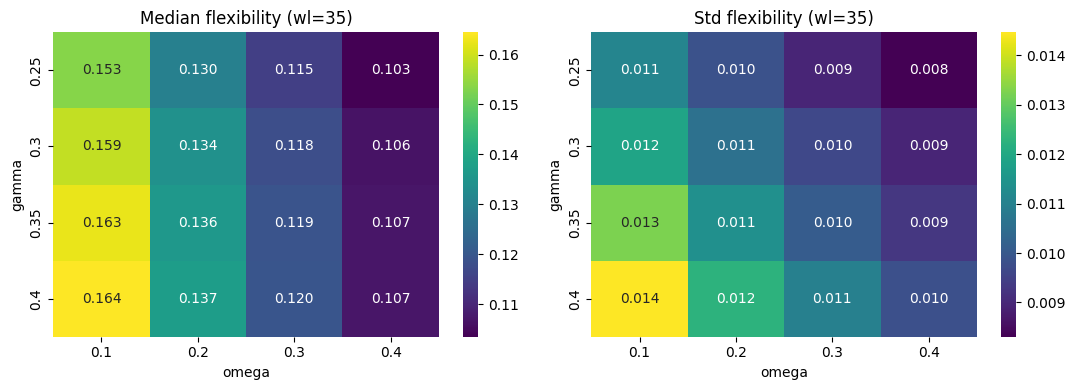

In [70]:
# Iterate over combos of window length 35 and display median and STD

df35 = window_length_stats[35].copy()

# combo is "gamma_<g>_omega_<o>" -- pull out the two parameter values as numeric
# columns so they can become the heatmap's row/column axes.
df35[["gamma", "omega"]] = df35["combo"].str.extract(r"gamma_([\d.]+)_omega_([\d.]+)").astype(float)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# pivot_table averages "median" over every other row (subject, date, dataset,
# condition) within each gamma/omega cell
sns.heatmap(df35.pivot_table(index="gamma", columns="omega", values="median"), annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Median flexibility (wl=35)")

# Same grid, but averaging the per-subject std instead -- shows where the
# gamma/omega combo makes flexibility more/less variable across subjects.
sns.heatmap(df35.pivot_table(index="gamma", columns="omega", values="std"), annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
axes[1].set_title("Std flexibility (wl=35)")

plt.tight_layout()
plt.show()

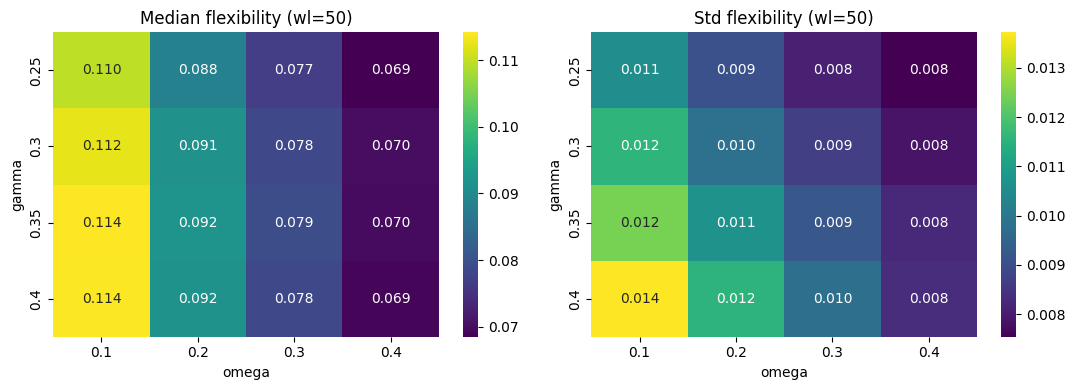

In [71]:
df50 = window_length_stats[50].copy()
df50[["gamma", "omega"]] = df50["combo"].str.extract(r"gamma_([\d.]+)_omega_([\d.]+)").astype(float)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(df50.pivot_table(index="gamma", columns="omega", values="median"), annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Median flexibility (wl=50)")

sns.heatmap(df50.pivot_table(index="gamma", columns="omega", values="std"), annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
axes[1].set_title("Std flexibility (wl=50)")

plt.tight_layout()
plt.show()

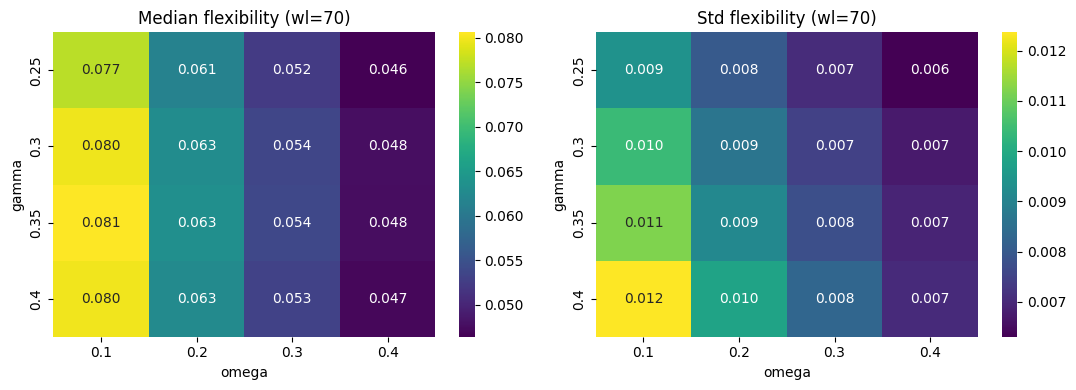

In [72]:
df70 = window_length_stats[70].copy()
df70[["gamma", "omega"]] = df70["combo"].str.extract(r"gamma_([\d.]+)_omega_([\d.]+)").astype(float)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(df70.pivot_table(index="gamma", columns="omega", values="median"), annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Median flexibility (wl=70)")

sns.heatmap(df70.pivot_table(index="gamma", columns="omega", values="std"), annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
axes[1].set_title("Std flexibility (wl=70)")

plt.tight_layout()
plt.show()

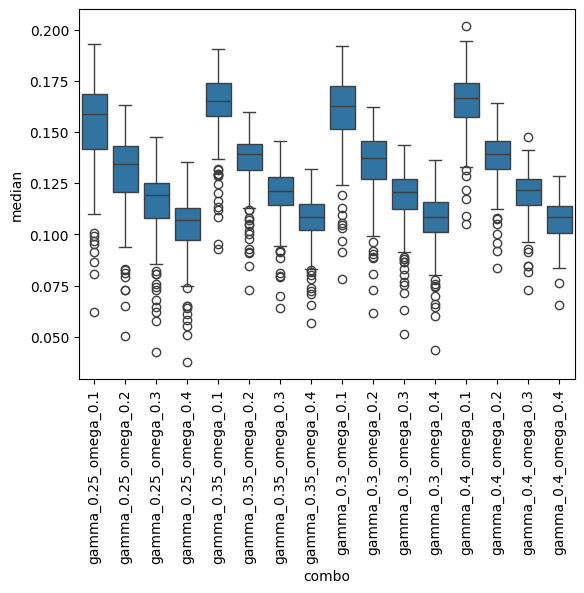

In [73]:
# Investigate the window length 35 specifically

# Use the combos gamma_omega as x axis with box plots and 
# And use the actual flexibility values as y axis

sns.boxplot(data=df35, x="combo", y="median")
plt.xticks(rotation=90)
plt.show()

# Use the combos gamma_omega as x axis with box plots and 
# And use the actual flexibility values as y axis


In [74]:
# Re-resolve the latest parameter-inspection run on each notebook execution.
PARAM_RUN_DIR = latest_param_inspection_run_dir(PARAM_INSPECTION_DIR)

{
    int(re.match(r"wl(\d+)$", os.path.basename(wl_dir)).group(1)): {
        "n_combos": len(parameter_dirs(wl_dir)),
        "example_datasets": sorted(
            os.path.basename(d)
            for d in glob(os.path.join(parameter_dirs(wl_dir)[0], "*"))
            if os.path.isdir(d)
        )[:4],
    }
    for wl_dir in width_dirs(PARAM_RUN_DIR)
}

{35: {'n_combos': 16,
  'example_datasets': ['Bf_DTA_anes',
   'Bf_DTA_awk',
   'Bf_PV_anes',
   'Bf_PV_awk']},
 50: {'n_combos': 16,
  'example_datasets': ['Bf_DTA_anes',
   'Bf_DTA_awk',
   'Bf_PV_anes',
   'Bf_PV_awk']},
 70: {'n_combos': 16,
  'example_datasets': ['Bf_DTA_anes', 'Bf_DTA_awk', 'Bf_PV_awk']}}

In [75]:
# Load every gamma/omega combo at window length 35 for Bf_DTA (anes + awk).
flex_wl35_dta = load_param_flex_long(
    run_dir=PARAM_RUN_DIR,
    window_length=35,
    datasets=(DATASET_ANES, DATASET_AWK),
)

flex_wl35_dta


,Node,flexibility,flexibility_std,gamma,interslice_weight,n_runs,n_windows,last_run,mouse_id,date,condition,phase,dataset,state,window_length,combo,omega
0,DMNa,0.156240,0.012214,0.25,0.1,10,650,20/06/2026 01:21,230908a,230908,EXP,NA,Bf_DTA,anes,35,gamma_0.25_omega_0.1,0.1
1,DMNp,0.167488,0.005684,0.25,0.1,10,650,20/06/2026 01:21,230908a,230908,EXP,NA,Bf_DTA,anes,35,gamma_0.25_omega_0.1,0.1
2,SAL,0.167026,0.011596,0.25,0.1,10,650,20/06/2026 01:21,230908a,230908,EXP,NA,Bf_DTA,anes,35,gamma_0.25_omega_0.1,0.1
3,OLF,0.192142,0.005808,0.25,0.1,10,650,20/06/2026 01:21,230908a,230908,EXP,NA,Bf_DTA,anes,35,gamma_0.25_omega_0.1,0.1
4,STR,0.186903,0.010105,0.25,0.1,10,650,20/06/2026 01:21,230908a,230908,EXP,NA,Bf_DTA,anes,35,gamma_0.25_omega_0.1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19179,HCa,0.116007,0.006478,0.40,0.4,10,607,26/06/2026 14:07,231130e,231130,EXP,NA,Bf_DTA,awk,35,gamma_0.4_omega_0.4,0.4
19180,SUB,0.111881,0.007941,0.40,0.4,10,607,26/06/2026 14:07,231130e,231130,EXP,NA,Bf_DTA,awk,35,gamma_0.4_omega_0.4,0.4
19181,CTXsp,0.100165,0.007119,0.40,0.4,10,607,26/06/2026 14:07,231130e,231130,EXP,NA,Bf_DTA,awk,35,gamma_0.4_omega_0.4,0.4
19182,BF,0.099340,0.007733,0.40,0.4,10,607,26/06/2026 14:07,231130e,231130,EXP,NA,Bf_DTA,awk,35,gamma_0.4_omega_0.4,0.4


In [76]:
# Subject inventory per combo / dataset / state / condition.
flex_wl35_dta.drop_duplicates(
    ["combo", "dataset", "state", "mouse_id", "condition"]
).groupby(["combo", "dataset", "state", "condition"])["mouse_id"].nunique()

combo                 dataset  state  condition
gamma_0.25_omega_0.1  Bf_DTA   anes   EXP          22
                                      SHAM         20
                               awk    EXP          16
                                      SHAM         17
gamma_0.25_omega_0.2  Bf_DTA   anes   EXP          22
                                                   ..
gamma_0.4_omega_0.3   Bf_DTA   awk    SHAM         17
gamma_0.4_omega_0.4   Bf_DTA   anes   EXP          22
                                      SHAM         20
                               awk    EXP          16
                                      SHAM         17
Name: mouse_id, Length: 64, dtype: int64

In [77]:
# Single-combo slice — same per-node/per-mouse layout as load_flex_long.
load_param_flex_long(
    run_dir=PARAM_RUN_DIR,
    window_length=35,
    combo="gamma_0.35_omega_0.4",
    datasets=(DATASET_ANES, DATASET_AWK),
).query("Node == 'VIS'")

,Node,flexibility,flexibility_std,gamma,interslice_weight,n_runs,n_windows,last_run,mouse_id,date,condition,phase,dataset,state,window_length,combo,omega
6,VIS,0.090139,0.009678,0.35,0.4,10,650,21/06/2026 14:36,230908a,230908,EXP,NA,Bf_DTA,anes,35,gamma_0.35_omega_0.4,0.4
22,VIS,0.090649,0.005974,0.35,0.4,10,664,21/06/2026 14:36,230911a,230911,SHAM,NA,Bf_DTA,anes,35,gamma_0.35_omega_0.4,0.4
38,VIS,0.102112,0.006679,0.35,0.4,10,664,21/06/2026 14:36,230911b,230911,EXP,NA,Bf_DTA,anes,35,gamma_0.35_omega_0.4,0.4
54,VIS,0.095692,0.008477,0.35,0.4,10,651,21/06/2026 14:36,230911c,230911,EXP,NA,Bf_DTA,anes,35,gamma_0.35_omega_0.4,0.4
70,VIS,0.099384,0.004584,0.35,0.4,10,650,21/06/2026 14:35,230911d,230911,SHAM,NA,Bf_DTA,anes,35,gamma_0.35_omega_0.4,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1110,VIS,0.087059,0.009883,0.35,0.4,10,681,26/06/2026 12:39,231116d,231116,SHAM,NA,Bf_DTA,awk,35,gamma_0.35_omega_0.4,0.4
1126,VIS,0.094240,0.006537,0.35,0.4,10,626,26/06/2026 12:38,231130a,231130,EXP,NA,Bf_DTA,awk,35,gamma_0.35_omega_0.4,0.4
1142,VIS,0.072462,0.009268,0.35,0.4,10,651,26/06/2026 12:39,231130b,231130,EXP,NA,Bf_DTA,awk,35,gamma_0.35_omega_0.4,0.4
1158,VIS,0.100628,0.006904,0.35,0.4,10,479,26/06/2026 12:38,231130c,231130,EXP,NA,Bf_DTA,awk,35,gamma_0.35_omega_0.4,0.4


In [78]:
# Run EXP vs SHAM t-tests for every combo at window length 35 (Bf_DTA only).
wl35_dta_tests = []
for combo in sorted(flex_wl35_dta["combo"].unique()):
    for state_code, state_label in [("anes", "anesthesia"), ("awk", "awake")]:
        flex_df = flex_wl35_dta.query("combo == @combo and state == @state_code")
        if flex_df.empty:
            continue
        res = exp_vs_sham_node_tests(flex_df, state=state_label)
        if res.empty:
            continue
        res["combo"] = combo
        res["dataset"] = "Bf_DTA"
        res["window_length"] = 35
        wl35_dta_tests.append(res)

wl35_dta_tests = (
    pd.concat(wl35_dta_tests, ignore_index=True)
    .sort_values(["combo", "state", "t_p_value", "Node"])
    .reset_index(drop=True)
    if wl35_dta_tests
    else pd.DataFrame(columns=[
        "state", "comparison", "Node",
        "t_p_value", "t_p_fdr", "hedges_g",
        "u_p_value", "u_p_fdr", "rank_biserial",
        "combo", "dataset", "window_length",
    ])
)
wl35_dta_tests.sort_values("u_p_fdr", ascending=True).head(20)

,state,comparison,Node,t_p_value,t_p_fdr,hedges_g,u_p_value,u_p_fdr,rank_biserial,combo,dataset,window_length
288,anesthesia,EXP_vs_SHAM,OLF,0.006167,0.098665,-0.880578,0.002122,0.033951,-0.556818,gamma_0.3_omega_0.2,Bf_DTA,35
322,anesthesia,EXP_vs_SHAM,SSs,0.033953,0.181082,-0.671412,0.007306,0.058448,-0.486364,gamma_0.3_omega_0.3,Bf_DTA,35
320,anesthesia,EXP_vs_SHAM,OLF,0.029242,0.181082,-0.690881,0.006519,0.058448,-0.493182,gamma_0.3_omega_0.3,Bf_DTA,35
32,anesthesia,EXP_vs_SHAM,SAL,0.040451,0.354561,-0.647474,0.010579,0.060315,-0.463636,gamma_0.25_omega_0.2,Bf_DTA,35
34,anesthesia,EXP_vs_SHAM,OLF,0.084710,0.354561,-0.545373,0.015079,0.060315,-0.440909,gamma_0.25_omega_0.2,Bf_DTA,35
38,anesthesia,EXP_vs_SHAM,VIS,0.155120,0.354561,-0.440746,0.014070,0.060315,-0.445455,gamma_0.25_omega_0.2,Bf_DTA,35
33,anesthesia,EXP_vs_SHAM,DMNp,0.053025,0.354561,-0.615801,0.014559,0.060315,-0.443182,gamma_0.25_omega_0.2,Bf_DTA,35
67,anesthesia,EXP_vs_SHAM,DMNa,0.071231,0.249157,-0.570776,0.016725,0.066899,-0.434091,gamma_0.25_omega_0.3,Bf_DTA,35
65,anesthesia,EXP_vs_SHAM,OLF,0.050110,0.249157,-0.619601,0.015615,0.066899,-0.438636,gamma_0.25_omega_0.3,Bf_DTA,35
66,anesthesia,EXP_vs_SHAM,SSs,0.055110,0.249157,-0.603925,0.005819,0.066899,-0.500000,gamma_0.25_omega_0.3,Bf_DTA,35


In [79]:
# FDR-significant nodes across all wl=35 Bf_DTA combos.
wl35_dta_tests.query("t_p_fdr < 0.05")[
    ["combo", "dataset", "window_length", "state", "Node", "t_p_value", "t_p_fdr", "hedges_g"]
]

,combo,dataset,window_length,state,Node,t_p_value,t_p_fdr,hedges_g


In [80]:
# Load every gamma/omega combo at window length 35 for Bf_DTA (anes + awk).
flex_wl50_dta = load_param_flex_long(
    run_dir=PARAM_RUN_DIR,
    window_length=50,
    datasets=(DATASET_ANES, DATASET_AWK),
)

flex_wl50_dta


,Node,flexibility,flexibility_std,gamma,interslice_weight,n_runs,n_windows,last_run,mouse_id,date,condition,phase,dataset,state,window_length,combo,omega
0,DMNa,0.116925,0.006946,0.25,0.1,10,645,21/06/2026 19:34,230908a,230908,EXP,NA,Bf_DTA,anes,50,gamma_0.25_omega_0.1,0.1
1,DMNp,0.121894,0.006597,0.25,0.1,10,645,21/06/2026 19:34,230908a,230908,EXP,NA,Bf_DTA,anes,50,gamma_0.25_omega_0.1,0.1
2,SAL,0.117081,0.004348,0.25,0.1,10,645,21/06/2026 19:34,230908a,230908,EXP,NA,Bf_DTA,anes,50,gamma_0.25_omega_0.1,0.1
3,OLF,0.136025,0.008222,0.25,0.1,10,645,21/06/2026 19:34,230908a,230908,EXP,NA,Bf_DTA,anes,50,gamma_0.25_omega_0.1,0.1
4,STR,0.124689,0.007351,0.25,0.1,10,645,21/06/2026 19:34,230908a,230908,EXP,NA,Bf_DTA,anes,50,gamma_0.25_omega_0.1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19083,HCa,0.085603,0.003503,0.40,0.4,10,640,26/06/2026 19:00,231130e,231130,EXP,NA,Bf_DTA,awk,50,gamma_0.4_omega_0.4,0.4
19084,SUB,0.083412,0.004902,0.40,0.4,10,640,26/06/2026 19:00,231130e,231130,EXP,NA,Bf_DTA,awk,50,gamma_0.4_omega_0.4,0.4
19085,CTXsp,0.070423,0.004642,0.40,0.4,10,640,26/06/2026 19:00,231130e,231130,EXP,NA,Bf_DTA,awk,50,gamma_0.4_omega_0.4,0.4
19086,BF,0.061972,0.005056,0.40,0.4,10,640,26/06/2026 19:00,231130e,231130,EXP,NA,Bf_DTA,awk,50,gamma_0.4_omega_0.4,0.4


In [81]:
# Run EXP vs SHAM t-tests for every combo at window length 35 (Bf_DTA only).
wl50_dta_tests = []
for combo in sorted(flex_wl50_dta["combo"].unique()):
    for state_code, state_label in [("anes", "anesthesia"), ("awk", "awake")]:
        flex_df = flex_wl50_dta.query("combo == @combo and state == @state_code")
        if flex_df.empty:
            continue
        res = exp_vs_sham_node_tests(flex_df, state=state_label)
        if res.empty:
            continue
        res["combo"] = combo
        res["dataset"] = "Bf_DTA"
        res["window_length"] = 50
        wl50_dta_tests.append(res)

wl50_dta_tests = (
    pd.concat(wl50_dta_tests, ignore_index=True)
    .sort_values(["combo", "state", "t_p_value", "Node"])
    .reset_index(drop=True)
    if wl50_dta_tests
    else pd.DataFrame(columns=[
        "state", "comparison", "Node",
        "t_p_value", "t_p_fdr", "hedges_g",
        "u_p_value", "u_p_fdr", "rank_biserial",
        "combo", "dataset", "window_length",
    ])
)
wl50_dta_tests.sort_values("u_p_fdr", ascending=True).head(20)

,state,comparison,Node,t_p_value,t_p_fdr,hedges_g,u_p_value,u_p_fdr,rank_biserial,combo,dataset,window_length
32,anesthesia,EXP_vs_SHAM,DMNp,0.013099,0.209577,-0.804977,0.000614,0.009824,-0.620455,gamma_0.25_omega_0.2,Bf_DTA,50
0,anesthesia,EXP_vs_SHAM,DMNp,0.021693,0.347092,-0.742399,0.001322,0.021154,-0.581818,gamma_0.25_omega_0.1,Bf_DTA,50
97,anesthesia,EXP_vs_SHAM,STR,0.048374,0.358074,-0.627985,0.002121,0.033937,-0.556818,gamma_0.25_omega_0.4,Bf_DTA,50
64,anesthesia,EXP_vs_SHAM,DMNp,0.034386,0.219046,-0.679353,0.002617,0.039846,-0.545455,gamma_0.25_omega_0.3,Bf_DTA,50
65,anesthesia,EXP_vs_SHAM,OLF,0.044515,0.219046,-0.639663,0.004981,0.039846,-0.509091,gamma_0.25_omega_0.3,Bf_DTA,50
96,anesthesia,EXP_vs_SHAM,SSp,0.026769,0.358074,-0.711134,0.006045,0.043859,-0.497727,gamma_0.25_omega_0.4,Bf_DTA,50
98,anesthesia,EXP_vs_SHAM,SSs,0.093718,0.358074,-0.524535,0.009473,0.043859,-0.470455,gamma_0.25_omega_0.4,Bf_DTA,50
99,anesthesia,EXP_vs_SHAM,DMNp,0.094511,0.358074,-0.527954,0.010965,0.043859,-0.461364,gamma_0.25_omega_0.4,Bf_DTA,50
35,anesthesia,EXP_vs_SHAM,DMNa,0.055620,0.222479,-0.607035,0.007883,0.045289,-0.481818,gamma_0.25_omega_0.2,Bf_DTA,50
33,anesthesia,EXP_vs_SHAM,OLF,0.048227,0.222479,-0.634204,0.008492,0.045289,-0.477273,gamma_0.25_omega_0.2,Bf_DTA,50


In [82]:
# Load every gamma/omega combo at window length 35 for Bf_DTA (anes + awk).
flex_wl70_dta = load_param_flex_long(
    run_dir=PARAM_RUN_DIR,
    window_length=70,
    datasets=(DATASET_ANES, DATASET_AWK),
)

flex_wl70_dta


,Node,flexibility,flexibility_std,gamma,interslice_weight,n_runs,n_windows,last_run,mouse_id,date,condition,phase,dataset,state,window_length,combo,omega
0,DMNa,0.078527,0.006990,0.25,0.1,10,639,22/06/2026 05:05,230908a,230908,EXP,NA,Bf_DTA,anes,70,gamma_0.25_omega_0.1,0.1
1,DMNp,0.095768,0.006517,0.25,0.1,10,639,22/06/2026 05:05,230908a,230908,EXP,NA,Bf_DTA,anes,70,gamma_0.25_omega_0.1,0.1
2,SAL,0.085580,0.004099,0.25,0.1,10,639,22/06/2026 05:05,230908a,230908,EXP,NA,Bf_DTA,anes,70,gamma_0.25_omega_0.1,0.1
3,OLF,0.098903,0.009071,0.25,0.1,10,639,22/06/2026 05:05,230908a,230908,EXP,NA,Bf_DTA,anes,70,gamma_0.25_omega_0.1,0.1
4,STR,0.105172,0.007882,0.25,0.1,10,639,22/06/2026 05:05,230908a,230908,EXP,NA,Bf_DTA,anes,70,gamma_0.25_omega_0.1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18955,HCa,0.060870,0.005288,0.40,0.4,10,668,27/06/2026 00:36,231130e,231130,EXP,NA,Bf_DTA,awk,70,gamma_0.4_omega_0.4,0.4
18956,SUB,0.057721,0.005073,0.40,0.4,10,668,27/06/2026 00:36,231130e,231130,EXP,NA,Bf_DTA,awk,70,gamma_0.4_omega_0.4,0.4
18957,CTXsp,0.051424,0.004500,0.40,0.4,10,668,27/06/2026 00:36,231130e,231130,EXP,NA,Bf_DTA,awk,70,gamma_0.4_omega_0.4,0.4
18958,BF,0.037181,0.006354,0.40,0.4,10,668,27/06/2026 00:36,231130e,231130,EXP,NA,Bf_DTA,awk,70,gamma_0.4_omega_0.4,0.4


In [83]:
# Run EXP vs SHAM t-tests for every combo at window length 35 (Bf_DTA only).
wl70_dta_tests = []
for combo in sorted(flex_wl70_dta["combo"].unique()):
    for state_code, state_label in [("anes", "anesthesia"), ("awk", "awake")]:
        flex_df = flex_wl70_dta.query("combo == @combo and state == @state_code")
        if flex_df.empty:
            continue
        res = exp_vs_sham_node_tests(flex_df, state=state_label)
        if res.empty:
            continue
        res["combo"] = combo
        res["dataset"] = "Bf_DTA"
        res["window_length"] = 70
        wl70_dta_tests.append(res)

wl70_dta_tests = (
    pd.concat(wl70_dta_tests, ignore_index=True)
    .sort_values(["combo", "state", "t_p_value", "Node"])
    .reset_index(drop=True)
    if wl70_dta_tests
    else pd.DataFrame(columns=[
        "state", "comparison", "Node",
        "t_p_value", "t_p_fdr", "hedges_g",
        "u_p_value", "u_p_fdr", "rank_biserial",
        "combo", "dataset", "window_length",
    ])
)
wl70_dta_tests.sort_values("t_p_fdr", ascending=True).head(20)

,state,comparison,Node,t_p_value,t_p_fdr,hedges_g,u_p_value,u_p_fdr,rank_biserial,combo,dataset,window_length
432,awake,EXP_vs_SHAM,HY,0.013794,0.220710,-0.895836,0.026736,0.396989,-0.455882,gamma_0.4_omega_0.2,Bf_DTA,70
400,awake,EXP_vs_SHAM,HY,0.025012,0.400185,-0.798223,0.032089,0.469019,-0.441176,gamma_0.4_omega_0.1,Bf_DTA,70
160,anesthesia,EXP_vs_SHAM,DMNp,0.027107,0.433711,-0.698986,0.033331,0.533295,-0.386364,gamma_0.35_omega_0.2,Bf_DTA,70
291,anesthesia,EXP_vs_SHAM,SSs,0.136613,0.466464,-0.462543,0.071742,0.229575,-0.327273,gamma_0.3_omega_0.2,Bf_DTA,70
292,anesthesia,EXP_vs_SHAM,VIS,0.145770,0.466464,-0.451752,0.060613,0.229575,-0.340909,gamma_0.3_omega_0.2,Bf_DTA,70
289,anesthesia,EXP_vs_SHAM,SSp,0.116244,0.466464,-0.494218,0.048027,0.229575,-0.359091,gamma_0.3_omega_0.2,Bf_DTA,70
290,anesthesia,EXP_vs_SHAM,STR,0.118173,0.466464,-0.491607,0.040119,0.229575,-0.372727,gamma_0.3_omega_0.2,Bf_DTA,70
288,anesthesia,EXP_vs_SHAM,DMNp,0.059268,0.466464,-0.597910,0.045268,0.229575,-0.363636,gamma_0.3_omega_0.2,Bf_DTA,70
433,awake,EXP_vs_SHAM,VIS,0.059549,0.476388,-0.674005,0.074573,0.397720,-0.367647,gamma_0.4_omega_0.2,Bf_DTA,70
293,anesthesia,EXP_vs_SHAM,DMNa,0.187289,0.499439,-0.410598,0.169842,0.406810,-0.250000,gamma_0.3_omega_0.2,Bf_DTA,70


## Parameter inspection - Bf_PV_awk CNO delta

Awake PV only: compute CNO - baseline within mouse, then compare EXP_delta vs SHAM_delta per node for each gamma/omega/window-length combo.

In [84]:
PV_AWK_PARAM_RUN_DIR = os.path.join(PARAM_INSPECTION_DIR, "2026_06_20__01-16-56")
assert os.path.isdir(PV_AWK_PARAM_RUN_DIR), PV_AWK_PARAM_RUN_DIR

pv_awk_delta_param_tests = run_parameter_pv_delta_tests(
    run_dir=PV_AWK_PARAM_RUN_DIR,
    dataset=DATASET_PV_AWK,
)

pv_awk_delta_param_tests = (
    pv_awk_delta_param_tests[
        [
            "combo", "dataset", "window_length", "state", "comparison", "Node",
            "t_p_value", "t_p_fdr", "hedges_g",
            "u_p_value", "u_p_fdr", "rank_biserial",
        ]
    ]
    .sort_values(["window_length", "combo", "t_p_value", "Node"])
    .reset_index(drop=True)
)

pv_awk_delta_param_tests

,combo,dataset,window_length,state,comparison,Node,t_p_value,t_p_fdr,hedges_g,u_p_value,u_p_fdr,rank_biserial
0,gamma_0.25_omega_0.1,Bf_PV,35,awake,EXP_vs_SHAM_delta,SAL,0.107857,0.837771,-0.764709,0.216373,0.767886,-0.358025
1,gamma_0.25_omega_0.1,Bf_PV,35,awake,EXP_vs_SHAM_delta,AUD,0.127125,0.837771,-0.722458,0.133320,0.767886,-0.432099
2,gamma_0.25_omega_0.1,Bf_PV,35,awake,EXP_vs_SHAM_delta,CTXsp,0.195926,0.837771,-0.605941,0.250998,0.767886,-0.333333
3,gamma_0.25_omega_0.1,Bf_PV,35,awake,EXP_vs_SHAM_delta,SSs,0.274690,0.837771,-0.507812,0.250998,0.767886,-0.333333
4,gamma_0.25_omega_0.1,Bf_PV,35,awake,EXP_vs_SHAM_delta,VIS,0.334474,0.837771,-0.446961,0.479929,0.767886,-0.209877
...,...,...,...,...,...,...,...,...,...,...,...,...
763,gamma_0.4_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,SSs,0.758068,0.953827,0.140920,0.723932,0.904093,0.111111
764,gamma_0.4_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,HCa,0.787619,0.953827,-0.123295,0.859819,0.917140,-0.061728
765,gamma_0.4_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,AUD,0.835511,0.953827,-0.094821,0.791082,0.904093,-0.086420
766,gamma_0.4_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,CTXsp,0.935118,0.953827,0.037407,0.377225,0.904093,0.259259


In [87]:
pv_awk_delta_param_top = (
    pv_awk_delta_param_tests
    .sort_values( "u_p_fdr")
    .head(20)
    .reset_index(drop=True)
)

pv_awk_delta_param_top

,combo,dataset,window_length,state,comparison,Node,t_p_value,t_p_fdr,hedges_g,u_p_value,u_p_fdr,rank_biserial
0,gamma_0.35_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,TH,0.048744,0.389951,0.988337,0.010444,0.167108,0.728395
1,gamma_0.35_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,SSs,0.023209,0.371336,1.140537,0.021684,0.173473,0.654321
2,gamma_0.35_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,OLF,0.073666,0.392887,0.859513,0.063690,0.309554,0.530864
3,gamma_0.35_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,CTXsp,0.188175,0.602159,0.619092,0.077389,0.309554,0.506173
4,gamma_0.4_omega_0.4,Bf_PV,35,awake,EXP_vs_SHAM_delta,AUD,0.038646,0.618331,-1.012108,0.021684,0.346946,-0.654321
5,gamma_0.35_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,BF,0.446307,0.609008,0.353634,0.111961,0.355521,0.456790
6,gamma_0.35_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,VIS,0.115807,0.463228,0.754971,0.133320,0.355521,0.432099
7,gamma_0.35_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,DMNp,0.309376,0.609008,0.473207,0.157704,0.360467,0.407407
8,gamma_0.35_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,HCa,0.490539,0.609008,0.317236,0.185326,0.370653,0.382716
9,gamma_0.35_omega_0.4,Bf_PV,70,awake,EXP_vs_SHAM_delta,SSp,0.333580,0.609008,0.453342,0.250998,0.401597,0.333333


In [88]:
pv_awk_delta_param_fdr_hits = (
    pv_awk_delta_param_tests
    .query("t_p_fdr < 0.05 or u_p_fdr < 0.05")
    .sort_values(["window_length", "combo", "t_p_fdr", "u_p_fdr", "Node"])
    .reset_index(drop=True)
)

pv_awk_delta_param_fdr_hits

,combo,dataset,window_length,state,comparison,Node,t_p_value,t_p_fdr,hedges_g,u_p_value,u_p_fdr,rank_biserial
